# Part 2A-ix: Custom Model — ResidualRegressor & ResidualBlock

**Objective:** Build custom models with skip connections using the subclassing API.

---

In [1]:
import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch, torch.nn as nn

(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_test = X_train.astype("float32")/255.0, X_test.astype("float32")/255.0
y_train, y_test = y_train.flatten(), y_test.flatten()
X_flat_tr, X_flat_te = X_train.reshape(len(X_train),-1), X_test.reshape(len(X_test),-1)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [2]:
# TF: Residual Block
class ResidualBlock(layers.Layer):
    """A residual block: output = F(x) + x
    If input/output dimensions differ, a projection shortcut is used.
    """
    def __init__(self, units, activation='relu', **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.dense1 = layers.Dense(units, activation=activation)
        self.dense2 = layers.Dense(units)
        self.bn1 = layers.BatchNormalization()
        self.bn2 = layers.BatchNormalization()
        self.activation = layers.Activation(activation)
        self.project = None

    def build(self, input_shape):
        if input_shape[-1] != self.units:
            self.project = layers.Dense(self.units)
        super().build(input_shape)

    def call(self, inputs, training=False):
        x = self.dense1(inputs)
        x = self.bn1(x, training=training)
        x = self.dense2(x)
        x = self.bn2(x, training=training)
        shortcut = self.project(inputs) if self.project else inputs
        return self.activation(x + shortcut)

# TF: Residual Classifier (custom model)
class ResidualClassifier(keras.Model):
    def __init__(self, n_classes=10, **kwargs):
        super().__init__(**kwargs)
        self.dense_in = layers.Dense(256, activation='relu')
        self.res_block1 = ResidualBlock(256)
        self.res_block2 = ResidualBlock(128)
        self.res_block3 = ResidualBlock(64)
        self.output_layer = layers.Dense(n_classes, activation='softmax')

    def call(self, inputs, training=False):
        x = self.dense_in(inputs)
        x = self.res_block1(x, training=training)
        x = self.res_block2(x, training=training)
        x = self.res_block3(x, training=training)
        return self.output_layer(x)

print("=== Training Residual Classifier ===")
model = ResidualClassifier()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h = model.fit(X_flat_tr, y_train, epochs=5, batch_size=256, validation_split=0.2, verbose=1)

loss, acc = model.evaluate(X_flat_te, y_test, verbose=0)
print(f"\nResidual Classifier Test Accuracy: {acc:.4f}")

=== Training Residual Classifier ===
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.3309 - loss: 1.8735 - val_accuracy: 0.3193 - val_loss: 1.9198
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4193 - loss: 1.6292 - val_accuracy: 0.3694 - val_loss: 1.8081
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4557 - loss: 1.5318 - val_accuracy: 0.3003 - val_loss: 2.1745
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4719 - loss: 1.4720 - val_accuracy: 0.3322 - val_loss: 2.0654
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4902 - loss: 1.4269 - val_accuracy: 0.3783 - val_loss: 1.7896

Residual Classifier Test Accuracy: 0.3815


=== Training Standard Model for comparison ===


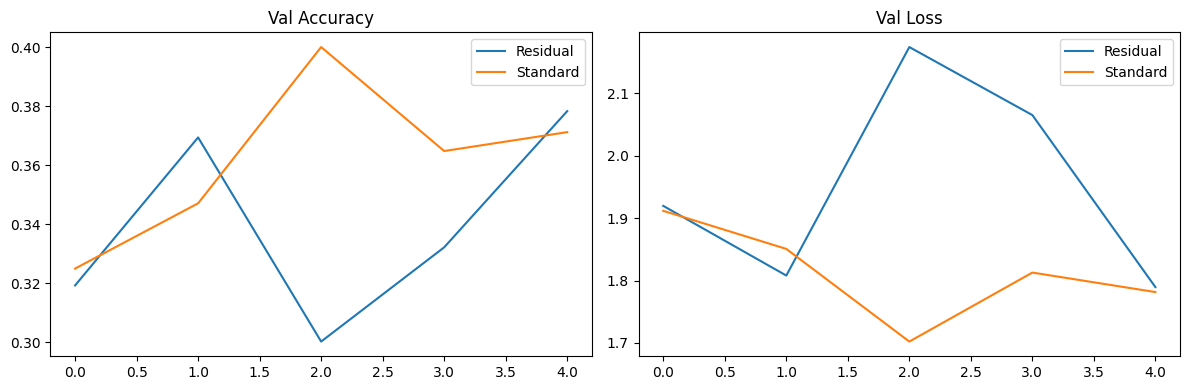

In [3]:
# Compare: Standard model vs Residual model
print("=== Training Standard Model for comparison ===")
model_std = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(256, activation='relu'), layers.BatchNormalization(),
    layers.Dense(256, activation='relu'), layers.BatchNormalization(),
    layers.Dense(128, activation='relu'), layers.BatchNormalization(),
    layers.Dense(64, activation='relu'), layers.BatchNormalization(),
    layers.Dense(10, activation='softmax')
])
model_std.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h_std = model_std.fit(X_flat_tr, y_train, epochs=5, batch_size=256, validation_split=0.2, verbose=0)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h.history['val_accuracy'], label='Residual')
ax[0].plot(h_std.history['val_accuracy'], label='Standard')
ax[0].set_title('Val Accuracy'); ax[0].legend()
ax[1].plot(h.history['val_loss'], label='Residual')
ax[1].plot(h_std.history['val_loss'], label='Standard')
ax[1].set_title('Val Loss'); ax[1].legend()
plt.tight_layout(); plt.show()

In [4]:
# PyTorch: Residual Model
class ResBlockPT(nn.Module):
    def __init__(self, in_f, out_f):
        super().__init__()
        self.main = nn.Sequential(
            nn.Linear(in_f, out_f), nn.BatchNorm1d(out_f), nn.ReLU(),
            nn.Linear(out_f, out_f), nn.BatchNorm1d(out_f))
        self.shortcut = nn.Linear(in_f, out_f) if in_f != out_f else nn.Identity()
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.main(x) + self.shortcut(x))

class ResidualClassifierPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3072, 256), nn.ReLU(),
            ResBlockPT(256, 256), ResBlockPT(256, 128), ResBlockPT(128, 64),
            nn.Linear(64, 10))
    def forward(self, x): return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pt_model = ResidualClassifierPT().to(device)
opt = torch.optim.Adam(pt_model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()
loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.FloatTensor(X_flat_tr), torch.LongTensor(y_train)),
    batch_size=256, shuffle=True)
for ep in range(5):
    pt_model.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); crit(pt_model(xb), yb).backward(); opt.step()
    if (ep+1) % 1 == 0:
        pt_model.eval()
        with torch.no_grad():
            acc = (pt_model(torch.FloatTensor(X_flat_te).to(device)).argmax(1)==torch.LongTensor(y_test).to(device)).float().mean()
        print(f"Epoch {ep+1}/5 — Test Acc: {acc:.4f}")

print(f"PyTorch Residual Classifier Test Acc: {acc:.4f}")

Epoch 1/5 — Test Acc: 0.3983
Epoch 2/5 — Test Acc: 0.3692
Epoch 3/5 — Test Acc: 0.3755
Epoch 4/5 — Test Acc: 0.4815
Epoch 5/5 — Test Acc: 0.4529
PyTorch Residual Classifier Test Acc: 0.4529


## Key Takeaways
- Residual/skip connections solve the vanishing gradient problem in deep networks
- `output = F(x) + x` — gradients flow directly through the skip connection
- Use projection shortcuts when input/output dimensions differ
- TF: subclass `keras.Model` for custom models with complex forward logic
- PyTorch: same pattern — subclass `nn.Module`
- Residual connections enable training of much deeper networks